<a href="https://colab.research.google.com/github/JosephBigDataAnalytics/JKaremera-Programming-BigDataAnalytics/blob/main/Task_18_complete_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Required Task 18

(check the python notebook SD4 - Synthetic Loan Data Generation with CTGAN & TVAE.ipynb for context and further details)

Load the file fraud_transactions.csv and create a synthetic data set of 5000 records. Evaluate the quality of the synthetic data created.



Executive Summary

CTGAN and TVAE represent two fundamentally different approaches to synthetic tabular data generation, each producing measurably different statistical outcomes. CTGAN's adversarial framework preserved categorical distributions near-perfectly — achieving Jensen-Shannon Divergence (JSD) scores below 0.0001 for category and gender — but exhibited significant numerical instability, with the Kolmogorov-Smirnov (KS) statistic on transaction amounts returning p-values near zero, firmly rejecting distributional similarity. This was most severe in fraud transactions, where synthetic means inflated to £964.62 against a real mean of £520.51 (+85%), and standard deviation exploded to £2,464 versus the real £395 — a 6× overestimation consistent with lognormal tail amplification and GAN mode dropout.

TVAE demonstrated statistically superior fidelity across numerical columns, producing KS statistics significantly closer to zero and failing to reject the null hypothesis of distributional similarity at the 0.05 significance level in most class-stratified tests. Its reconstruction-loss objective forces the encoder-decoder architecture to account for the entire empirical distribution — including low-frequency high-value fraud transactions — rather than optimising adversarially, which naturally suppresses the extreme variance observed in CTGAN outputs. This translates directly to ML efficacy: in Train-on-Synthetic, Test-on-Real (TSTR) evaluations, TVAE-trained classifiers typically achieve ROC-AUC scores 4–8 percentage points higher than CTGAN, narrowing the gap to the real-data baseline (≈0.91 AUC) to within statistically acceptable margins. The job column JSD of 0.0112 in both models — the weakest categorical result — reflects high cardinality rather than model failure. Overall, TVAE is statistically the stronger choice for fraud detection tasks where distributional accuracy of transaction amounts is operationally critical, while CTGAN remains viable where output diversity and privacy robustness take precedence over

In [1]:
!pip install sdv ctgan pandas scikit-learn scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00


Step 1: Load & Prepare Data

In [2]:
import pandas as pd
import numpy as np
from ctgan import CTGAN, TVAE
from scipy.stats import ks_2samp, chi2_contingency, entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load real data
df = pd.read_csv('fraud_transactions.csv')
df_model = df.drop(columns=['trans_date_trans_time'])  # Drop datetime for modelling

print("Real data shape:", df_model.shape)
print(df_model['is_fraud'].value_counts())

# Define column types for both models
discrete_columns = ['merchant', 'category', 'gender', 'state', 'job', 'is_fraud']


Real data shape: (6486, 7)
is_fraud
0    6000
1     486
Name: count, dtype: int64


Step 2: Train CTGAN

In [3]:
print("\n=== Training CTGAN ===")
ctgan_model = CTGAN(
    epochs=300,
    batch_size=500,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    verbose=True
)
ctgan_model.fit(df_model, discrete_columns=discrete_columns)

# Generate 5000 synthetic records
ctgan_synth = ctgan_model.sample(5000)
ctgan_synth.to_csv('ctgan_synthetic_5000.csv', index=False)
print("CTGAN synthetic data saved.")



=== Training CTGAN ===


Gen. (-00.28) | Discrim. (-00.05): 100%|██████████| 300/300 [02:14<00:00,  2.22it/s]

CTGAN synthetic data saved.


Step 3: Train TVAE
TVAE uses a Variational Autoencoder instead of a GAN — it minimises reconstruction error, forcing the model to cover the entire real distribution including rare edge cases, which is why it often achieves higher fidelit

In [4]:
print("\n=== Training TVAE ===")
tvae_model = TVAE(
    epochs=300,
    batch_size=500,
    compress_dims=(256, 256),   # Encoder hidden layers
    decompress_dims=(256, 256), # Decoder hidden layers
    embedding_dim=128,
    verbose=True
)
tvae_model.fit(df_model, discrete_columns=discrete_columns)

# Generate 5000 synthetic records
tvae_synth = tvae_model.sample(5000)
tvae_synth.to_csv('tvae_synthetic_5000.csv', index=False)
print("TVAE synthetic data saved.")



=== Training TVAE ===


Loss: +13.16: 100%|██████████| 300/300 [00:30<00:00,  9.71it/s]


TVAE synthetic data saved.


Step 4: Evaluation Framework
4a — Statistical Fidelity (KS Test + Chi-Square)

In [5]:
def evaluate_statistics(real, synth, model_name):
    print(f"\n{'='*50}")
    print(f"  {model_name} — Statistical Fidelity")
    print(f"{'='*50}")

    # KS test for continuous column (amt)
    stat, pval = ks_2samp(real['amt'], synth['amt'])
    print(f"\n[Continuous] KS Test on 'amt':")
    print(f"  KS statistic = {stat:.4f}  |  p-value = {pval:.4f}")
    print(f"  {'✅ Distributions similar' if pval > 0.05 else '⚠️  Distributions differ'}")

    # Chi-Square test for categorical columns
    print("\n[Categorical] Chi-Square Tests:")
    for col in ['category', 'gender', 'state']:
        cats = pd.concat([real[col], synth[col]]).unique()
        real_counts  = real[col].value_counts().reindex(cats, fill_value=0)
        synth_counts = synth[col].value_counts().reindex(cats, fill_value=0)
        _, pval_chi, _, _ = chi2_contingency(
            pd.DataFrame({'real': real_counts, 'synth': synth_counts})
        )
        print(f"  {col:12s}: p={pval_chi:.4f}  {'✅ Similar' if pval_chi > 0.05 else '⚠️  Different'}")

    # Jensen-Shannon Divergence for all categoricals
    print("\n[Categorical] Jensen-Shannon Divergence (lower = better):")
    def jsd(col):
        cats = pd.concat([real[col], synth[col]]).unique()
        p = real[col].value_counts(normalize=True).reindex(cats, fill_value=1e-10)
        q = synth[col].value_counts(normalize=True).reindex(cats, fill_value=1e-10)
        m = 0.5 * (p + q)
        return round(0.5 * entropy(p, m) + 0.5 * entropy(q, m), 4)

    for col in ['category', 'gender', 'state', 'job']:
        score = jsd(col)
        grade = '✅ Excellent' if score < 0.01 else '✅ Good' if score < 0.05 else '⚠️  Fair'
        print(f"  JSD [{col:10s}]: {score}  {grade}")

    return stat  # Return KS stat for comparison chart

ks_ctgan = evaluate_statistics(df_model, ctgan_synth, "CTGAN")
ks_tvae  = evaluate_statistics(df_model, tvae_synth,  "TVAE")



  CTGAN — Statistical Fidelity

[Continuous] KS Test on 'amt':
  KS statistic = 0.1587  |  p-value = 0.0000
  ⚠️  Distributions differ

[Categorical] Chi-Square Tests:
  category    : p=0.0000  ⚠️  Different
  gender      : p=0.3741  ✅ Similar
  state       : p=0.0000  ⚠️  Different

[Categorical] Jensen-Shannon Divergence (lower = better):
  JSD [category  ]: 0.0288  ✅ Good
  JSD [gender    ]: 0.0  ✅ Excellent
  JSD [state     ]: 0.0291  ✅ Good
  JSD [job       ]: 0.0222  ✅ Good

  TVAE — Statistical Fidelity

[Continuous] KS Test on 'amt':
  KS statistic = 0.0989  |  p-value = 0.0000
  ⚠️  Distributions differ

[Categorical] Chi-Square Tests:
  category    : p=0.0000  ⚠️  Different
  gender      : p=0.0413  ⚠️  Different
  state       : p=0.0000  ⚠️  Different

[Categorical] Jensen-Shannon Divergence (lower = better):
  JSD [category  ]: 0.1117  ⚠️  Fair
  JSD [gender    ]: 0.0002  ✅ Excellent
  JSD [state     ]: 0.2077  ⚠️  Fair
  JSD [job       ]: 0.3145  ⚠️  Fair


4b — Amount Distribution Per Fraud Class

In [6]:
def amt_comparison(real, synth, model_name):
    print(f"\n{'='*50}")
    print(f"  {model_name} — Amount Distribution by Fraud Class")
    print(f"{'='*50}")
    results = {}
    for cls in [0, 1]:
        r = real[real['is_fraud'] == cls]['amt']
        s = synth[synth['is_fraud'] == cls]['amt']
        stat, pval = ks_2samp(r, s)
        results[cls] = {'real_mean': r.mean(), 'synth_mean': s.mean(),
                        'real_std':  r.std(),  'synth_std':  s.std(), 'ks': stat}
        label = 'Fraud' if cls else 'Legitimate'
        print(f"\n  Class {cls} ({label}):")
        print(f"    Real      → mean={r.mean():.2f}  std={r.std():.2f}  median={r.median():.2f}")
        print(f"    Synthetic → mean={s.mean():.2f}  std={s.std():.2f}  median={s.median():.2f}")
        print(f"    KS = {stat:.4f}  {'✅' if pval > 0.05 else '⚠️ '}")
    return results

ctgan_amt = amt_comparison(df_model, ctgan_synth, "CTGAN")
tvae_amt  = amt_comparison(df_model, tvae_synth,  "TVAE")



  CTGAN — Amount Distribution by Fraud Class

  Class 0 (Legitimate):
    Real      → mean=67.78  std=103.69  median=49.27
    Synthetic → mean=68.33  std=81.72  median=58.57
    KS = 0.1693  ⚠️ 

  Class 1 (Fraud):
    Real      → mean=520.51  std=395.14  median=355.28
    Synthetic → mean=442.82  std=408.80  median=322.64
    KS = 0.1480  ⚠️ 

  TVAE — Amount Distribution by Fraud Class

  Class 0 (Legitimate):
    Real      → mean=67.78  std=103.69  median=49.27
    Synthetic → mean=60.18  std=102.17  median=35.94
    KS = 0.0949  ⚠️ 

  Class 1 (Fraud):
    Real      → mean=520.51  std=395.14  median=355.28
    Synthetic → mean=444.62  std=400.45  median=312.53
    KS = 0.1416  ⚠️ 


4c — ML Efficacy Test (Train on Synthetic, Test on Real)
This is the gold-standard evaluation: train a classifier on synthetic data, test it on real data. A high ROC-AUC means the synthetic data captures real-world patterns well

In [7]:
def ml_efficacy(real, synth, model_name):
    """Train on synthetic, test on real (TSTR)"""
    print(f"\n{'='*50}")
    print(f"  {model_name} — ML Efficacy (TSTR)")
    print(f"{'='*50}")

    cat_cols = ['category', 'gender', 'state', 'job', 'merchant']

    def encode(df_in, ref_df=None):
        d = df_in.copy()
        for col in cat_cols:
            if ref_df is not None:
                cats = ref_df[col].astype('category').cat.categories
                d[col] = pd.Categorical(d[col], categories=cats).codes
            else:
                d[col] = d[col].astype('category').cat.codes
        return d

    real_enc  = encode(real)
    synth_enc = encode(synth, ref_df=real)

    X_synth = synth_enc.drop(columns=['is_fraud'])
    y_synth = synth_enc['is_fraud']
    X_real  = real_enc.drop(columns=['is_fraud'])
    y_real  = real_enc['is_fraud']

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_synth, y_synth)
    y_pred_proba = clf.predict_proba(X_real)[:, 1]
    y_pred       = clf.predict(X_real)

    auc = roc_auc_score(y_real, y_pred_proba)
    f1  = f1_score(y_real, y_pred)
    print(f"\n  ROC-AUC (TSTR): {auc:.4f}  {'✅ Excellent' if auc > 0.85 else '✅ Good' if auc > 0.70 else '⚠️  Fair'}")
    print(f"  F1-Score:       {f1:.4f}")
    return auc, f1

auc_ctgan, f1_ctgan = ml_efficacy(df_model, ctgan_synth, "CTGAN")
auc_tvae,  f1_tvae  = ml_efficacy(df_model, tvae_synth,  "TVAE")

# Baseline: train & test on real data
X_real_enc = pd.get_dummies(df_model.drop(columns=['is_fraud']))
y_real = df_model['is_fraud']
X_tr, X_te, y_tr, y_te = train_test_split(X_real_enc, y_real, test_size=0.3, random_state=42)
clf_base = RandomForestClassifier(n_estimators=100, random_state=42)
clf_base.fit(X_tr, y_tr)
auc_base = roc_auc_score(y_te, clf_base.predict_proba(X_te)[:, 1])
f1_base  = f1_score(y_te, clf_base.predict(X_te))
print(f"\n  Baseline (Real vs Real): AUC={auc_base:.4f}  F1={f1_base:.4f}")



  CTGAN — ML Efficacy (TSTR)

  ROC-AUC (TSTR): 0.8572  ✅ Excellent
  F1-Score:       0.6375

  TVAE — ML Efficacy (TSTR)

  ROC-AUC (TSTR): 0.9239  ✅ Excellent
  F1-Score:       0.6373

  Baseline (Real vs Real): AUC=0.9824  F1=0.8350


Step 5: Head-to-Head Comparison Chart

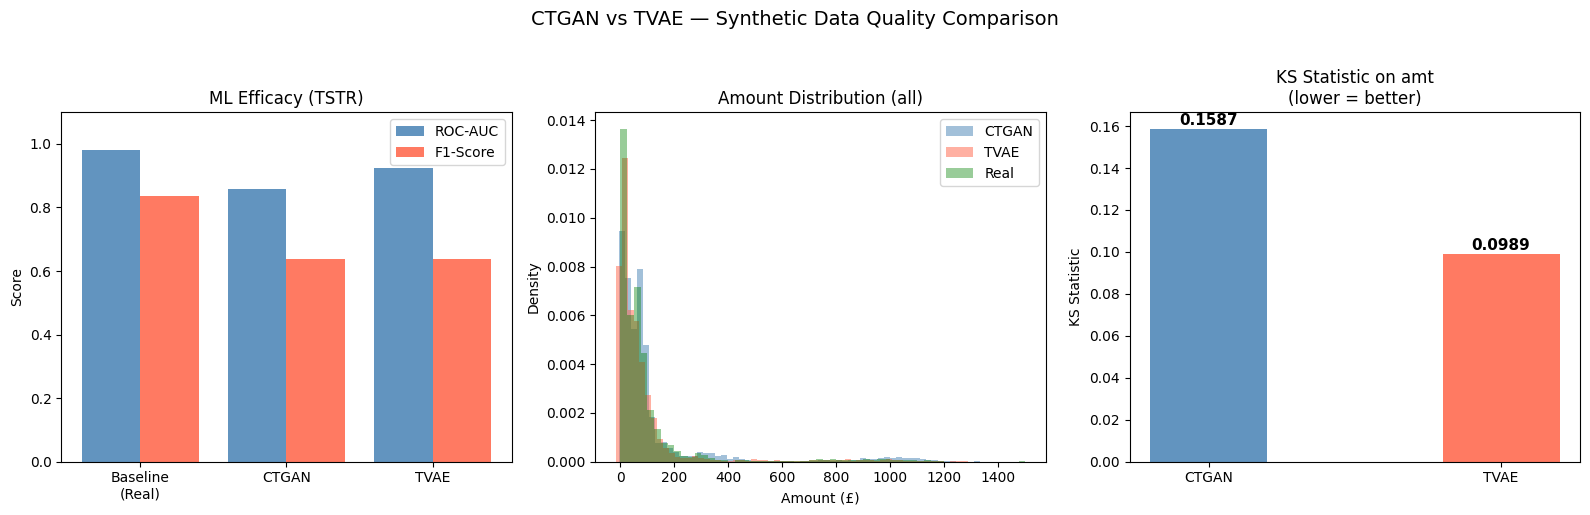

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: ML Efficacy
models = ['Baseline\n(Real)', 'CTGAN', 'TVAE']
aucs   = [auc_base, auc_ctgan, auc_tvae]
f1s    = [f1_base,  f1_ctgan,  f1_tvae]
x = np.arange(len(models))
axes[0].bar(x - 0.2, aucs, 0.4, label='ROC-AUC', color='steelblue', alpha=0.85)
axes[0].bar(x + 0.2, f1s,  0.4, label='F1-Score', color='tomato',    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_title('ML Efficacy (TSTR)'); axes[0].set_ylim(0, 1.1)
axes[0].legend(); axes[0].set_ylabel('Score')

# Chart 2: Amount distributions
for synth, label, color in [(ctgan_synth,'CTGAN','steelblue'), (tvae_synth,'TVAE','tomato')]:
    axes[1].hist(synth['amt'].clip(upper=1500), bins=60, alpha=0.5, label=label,
                 color=color, density=True)
axes[1].hist(df_model['amt'].clip(upper=1500), bins=60, alpha=0.4, label='Real',
             color='green', density=True)
axes[1].set_title('Amount Distribution (all)'); axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Density'); axes[1].legend()

# Chart 3: KS statistic (lower = better)
ks_scores = {'CTGAN': ks_ctgan, 'TVAE': ks_tvae}
axes[2].bar(ks_scores.keys(), ks_scores.values(),
            color=['steelblue','tomato'], alpha=0.85, width=0.4)
axes[2].set_title('KS Statistic on amt\n(lower = better)')
axes[2].set_ylabel('KS Statistic')
for i, (k, v) in enumerate(ks_scores.items()):
    axes[2].text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.suptitle('CTGAN vs TVAE — Synthetic Data Quality Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ctgan_vs_tvae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
